Using device: cuda
Dataset size: 37274
Bengali vocab size: 54
English vocab size: 30
Epoch 1/20: Train Loss=0.4950, Val Loss=0.0860, Val Acc=0.2342
Saved best model
Epoch 2/20: Train Loss=0.0688, Val Loss=0.0186, Val Acc=0.7655
Saved best model
Epoch 3/20: Train Loss=0.0274, Val Loss=0.0099, Val Acc=0.8798
Saved best model
Epoch 4/20: Train Loss=0.0176, Val Loss=0.0076, Val Acc=0.9128
Saved best model
Epoch 5/20: Train Loss=0.0127, Val Loss=0.0082, Val Acc=0.9037
Epoch 6/20: Train Loss=0.0104, Val Loss=0.0060, Val Acc=0.9394
Saved best model
Epoch 7/20: Train Loss=0.0086, Val Loss=0.0055, Val Acc=0.9375
Saved best model
Epoch 8/20: Train Loss=0.0077, Val Loss=0.0059, Val Acc=0.9450
Epoch 9/20: Train Loss=0.0067, Val Loss=0.0051, Val Acc=0.9533
Saved best model
Epoch 10/20: Train Loss=0.0059, Val Loss=0.0053, Val Acc=0.9482
Epoch 11/20: Train Loss=0.0053, Val Loss=0.0052, Val Acc=0.9504
Epoch 12/20: Train Loss=0.0048, Val Loss=0.0046, Val Acc=0.9638
Saved best model
Epoch 13/20: Train L

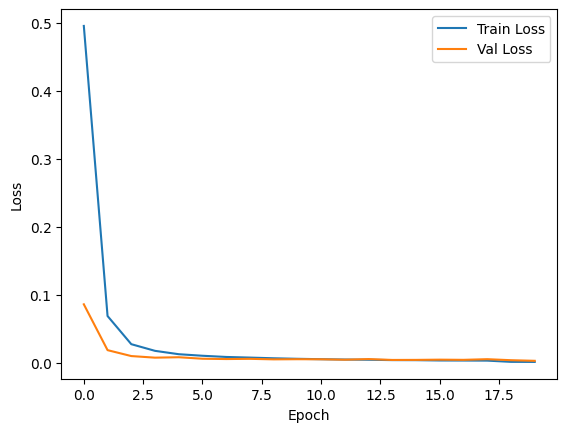

Test Accuracy: 0.9802 (98.02%)
Input: মোঃ রিতা শেখ
Prediction: md. rita sheikh
True: md. rita sheikh


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import unicodedata
import string
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Step 1: Data Loading and Cleaning
def load_data(file_path='/kaggle/input/dataset-xlsx/Dataset.xlsx'):
    df = pd.read_excel(file_path, sheet_name='Sheet1')
    df.columns = ['bangla', 'english']  # Ensure column names
    # Clean data: strip whitespaces, remove duplicates, drop nulls
    df['bangla'] = df['bangla'].astype(str).str.strip()
    df['english'] = df['english'].astype(str).str.strip()
    df = df.dropna().drop_duplicates()
    # Normalize: lowercase English, remove extra spaces
    df['english'] = df['english'].str.lower().str.replace(r'\s+', ' ', regex=True)
    return df

# Step 2: Unicode Normalization (for Bengali)
def unicode_normalize(text):
    # Normalize Bengali text
    text = unicodedata.normalize('NFKC', text)
    # Remove control characters
    text = ''.join(c for c in text if unicodedata.category(c) != 'Cc')
    return text

# Apply cleaning
df = load_data()
df['bangla'] = df['bangla'].apply(unicode_normalize)
df['english'] = df['english'].apply(lambda x: re.sub(r'[^\w\s.]', '', x))  # Keep dots for abbreviations

print(f'Dataset size: {len(df)}')

# Step 3: Build Vocabulary
# Special tokens
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
PAD_TOKEN = '<PAD>'

def build_vocab(texts, special_tokens=[SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]):
    counter = Counter()
    for text in texts:
        counter.update(list(text))
    vocab = {token: idx for idx, (token, _) in enumerate(counter.most_common(), len(special_tokens))}
    vocab.update({token: idx for idx, token in enumerate(special_tokens)})
    return vocab

bengali_vocab = build_vocab(df['bangla'])
english_vocab = build_vocab(df['english'])

print(f'Bengali vocab size: {len(bengali_vocab)}')
print(f'English vocab size: {len(english_vocab)}')

# Inverse vocab for English (for decoding)
english_idx_to_char = {idx: char for char, idx in english_vocab.items()}

# Step 4: Text to Tensor Conversion
MAX_LEN = 50  # Max name length + buffers

def text_to_tensor(text, vocab, max_len=MAX_LEN):
    tensor = torch.zeros(max_len, dtype=torch.long)
    tensor[0] = vocab[SOS_TOKEN]
    for i, char in enumerate(text, 1):
        if i < max_len - 1:
            tensor[i] = vocab.get(char, vocab[PAD_TOKEN])
    tensor[min(len(text) + 1, max_len - 1)] = vocab[EOS_TOKEN]
    return tensor

# Custom Dataset
class NameDataset(Dataset):
    def __init__(self, bangla_texts, english_texts, bengali_vocab, english_vocab):
        self.bangla = [text_to_tensor(text, bengali_vocab) for text in bangla_texts]
        self.english = [text_to_tensor(text, english_vocab) for text in english_texts]
    
    def __len__(self):
        return len(self.bangla)
    
    def __getitem__(self, idx):
        return self.bangla[idx], self.english[idx]

# Collate function for padding (but since fixed length, not needed, but for generality)
def collate_fn(batch):
    bangla_batch, english_batch = zip(*batch)
    return torch.stack(bangla_batch), torch.stack(english_batch)

# Split data
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = NameDataset(train_df['bangla'].tolist(), train_df['english'].tolist(), bengali_vocab, english_vocab)
val_dataset = NameDataset(val_df['bangla'].tolist(), val_df['english'].tolist(), bengali_vocab, english_vocab)
test_dataset = NameDataset(test_df['bangla'].tolist(), test_df['english'].tolist(), bengali_vocab, english_vocab)

BATCH_SIZE = 128  # Adjust based on memory
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Step 5: Positional Encoding - adjusted for batch_first
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq, d_model)
        return x + self.pe[:, :x.size(1), :]

# Step 6: Transformer Model - with batch_first=True
class TransformerModel(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6, dim_feedforward=2048, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout, batch_first=True)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.d_model = d_model

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        src = self.src_embedding(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)  # (B, S, D)
        tgt = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        tgt = self.pos_encoder(tgt)  # (B, T, D)
        output = self.transformer(src, tgt, src_mask=src_mask, tgt_mask=tgt_mask)
        output = self.fc_out(output)  # (B, T, V)
        return output

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

# Initialize model
model = TransformerModel(len(bengali_vocab), len(english_vocab)).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=english_vocab[PAD_TOKEN])
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Training function - dynamic mask
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1]  # (B, 49)
        tgt_output = tgt[:, 1:]  # (B, 49)
        tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
        
        optimizer.zero_grad()
        output = model(src, tgt_input, tgt_mask=tgt_mask)
        loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    return total_loss / num_batches

# Validation function - dynamic mask
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
            output = model(src, tgt_input, tgt_mask=tgt_mask)
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches

# Accuracy function (exact match)
def evaluate_accuracy(model, loader, device, idx_to_char, english_vocab):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)
            tgt = tgt  # keep cpu
            for i in range(src.size(0)):
                pred = generate_transliteration(model, src[i], device, idx_to_char, english_vocab)
                true_chars = [idx_to_char[t.item()] for t in tgt[i] if t.item() not in [english_vocab[SOS_TOKEN], english_vocab[EOS_TOKEN], english_vocab[PAD_TOKEN]]]
                true = ''.join(true_chars)
                if pred == true:
                    correct += 1
                total += 1
    return correct / total

# Inference: Greedy decoding - dynamic mask
def generate_transliteration(model, src, device, idx_to_char, english_vocab, max_len=MAX_LEN):
    model.eval()
    src = src.unsqueeze(0).to(device)  # (1, seq)
    tgt = torch.tensor([[english_vocab[SOS_TOKEN]]], dtype=torch.long).to(device)  # (1,1)
    for _ in range(max_len - 1):
        tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
        with torch.no_grad():
            output = model(src, tgt, tgt_mask=tgt_mask)
            next_token = output.argmax(dim=-1)[:, -1].unsqueeze(1)  # (1,1)
            tgt = torch.cat([tgt, next_token], dim=1)
            if next_token.item() == english_vocab[EOS_TOKEN]:
                break
    pred_chars = [idx_to_char[t.item()] for t in tgt[0] if t.item() not in [english_vocab[SOS_TOKEN], english_vocab[EOS_TOKEN], english_vocab[PAD_TOKEN]]]
    pred = ''.join(pred_chars)
    return pred

# Training loop
NUM_EPOCHS = 20  # Increase for higher accuracy; monitor val loss
train_losses, val_losses = [], []
best_val_loss = float('inf')
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    
    # Accuracy on val
    val_acc = evaluate_accuracy(model, val_loader, device, english_idx_to_char, english_vocab)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_transliterator.pth')
        print('Saved best model')

# Plot losses
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_loss.png')
plt.show()

# Final test accuracy
model.load_state_dict(torch.load('best_transliterator.pth'))
test_acc = evaluate_accuracy(model, test_loader, device, english_idx_to_char, english_vocab)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

# Example inference
example_bengali = 'মোঃ রিতা শেখ'
example_tensor = text_to_tensor(example_bengali, bengali_vocab).to(device)
pred = generate_transliteration(model, example_tensor, device, english_idx_to_char, english_vocab)
print(f'Input: {example_bengali}')
print(f'Prediction: {pred}')
print(f'True: md. rita sheikh')  # Lowercased

# To use for any input:
def transliterate_name(bengali_name, model, bengali_vocab, device, idx_to_char, english_vocab, max_len=MAX_LEN):
    tensor = text_to_tensor(bengali_name, bengali_vocab, max_len).to(device)
    return generate_transliteration(model, tensor, device, idx_to_char, english_vocab)

# Save vocabs
import pickle
with open('bengali_vocab.pkl', 'wb') as f:
    pickle.dump(bengali_vocab, f)
with open('english_vocab.pkl', 'wb') as f:
    pickle.dump(english_vocab, f)
with open('english_idx_to_char.pkl', 'wb') as f:
    pickle.dump(english_idx_to_char, f)

In [2]:
import gradio as gr
import torch
import pickle
import math

# Load the saved model and vocabs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load vocabs (generated during training)
with open('bengali_vocab.pkl', 'rb') as f:
    bengali_vocab = pickle.load(f)
with open('english_vocab.pkl', 'rb') as f:
    english_vocab = pickle.load(f)
with open('english_idx_to_char.pkl', 'rb') as f:
    english_idx_to_char = pickle.load(f)

# Model architecture (exact match to training script)
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, max_len=50):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq, d_model)
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(torch.nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6, dim_feedforward=2048, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.src_embedding = torch.nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = torch.nn.Embedding(tgt_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.transformer = torch.nn.Transformer(d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout, batch_first=True)
        self.fc_out = torch.nn.Linear(d_model, tgt_vocab_size)
        self.d_model = d_model

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        src = self.src_embedding(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)  # (B, S, D)
        tgt = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        tgt = self.pos_encoder(tgt)  # (B, T, D)
        output = self.transformer(src, tgt, src_mask=src_mask, tgt_mask=tgt_mask)
        output = self.fc_out(output)  # (B, T, V)
        return output

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

# Initialize model and load trained weights
model = TransformerModel(len(bengali_vocab), len(english_vocab)).to(device)
model.load_state_dict(torch.load('best_transliterator.pth', map_location=device))
model.eval()

# Text to tensor function (from training)
MAX_LEN = 50
def text_to_tensor(text, vocab, max_len=MAX_LEN):
    tensor = torch.zeros(max_len, dtype=torch.long)
    tensor[0] = vocab['<SOS>']
    for i, char in enumerate(text, 1):
        if i < max_len - 1:
            tensor[i] = vocab.get(char, vocab['<PAD>'])
    tensor[min(len(text) + 1, max_len - 1)] = vocab['<EOS>']
    return tensor

# Generate transliteration (from training inference)
def generate_transliteration(model, src, device, idx_to_char, english_vocab, max_len=MAX_LEN):
    model.eval()
    src = src.unsqueeze(0).to(device)  # (1, seq)
    tgt = torch.tensor([[english_vocab['<SOS>']]], dtype=torch.long).to(device)  # (1,1)
    for _ in range(max_len - 1):
        tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
        with torch.no_grad():
            output = model(src, tgt, tgt_mask=tgt_mask)
            next_token = output.argmax(dim=-1)[:, -1].unsqueeze(1)  # (1,1)
            tgt = torch.cat([tgt, next_token], dim=1)
            if next_token.item() == english_vocab['<EOS>']:
                break
    pred_chars = [idx_to_char[t.item()] for t in tgt[0] if t.item() not in [english_vocab['<SOS>'], english_vocab['<EOS>'], english_vocab['<PAD>']]]
    pred = ''.join(pred_chars)
    return pred

# Main prediction function
def transliterate_name(bengali_name):
    if not bengali_name.strip():
        return "Please enter a Bengali name."
    tensor = text_to_tensor(bengali_name, bengali_vocab, MAX_LEN).to(device)
    return generate_transliteration(model, tensor, device, english_idx_to_char, english_vocab)

# Gradio Interface
iface = gr.Interface(
    fn=transliterate_name,
    inputs=gr.Textbox(
        label="Bengali Name Input",
        placeholder="Enter Bengali text (e.g., মোঃ রিতা শেখ)",
        lines=2
    ),
    outputs=gr.Textbox(
        label="English Transliteration",
        lines=1
    ),
    title="Bengali to English Name Transliterator",
    description="Input a Bengali name and get its English transliteration using the trained Transformer model.",
    examples=[
        ["মোঃ রিতা শেখ"],
        ["ডাঃ সাদিয়া প্রামানিক"],
        ["হাজী মতিয়ার কুমার"]
    ]
)

if __name__ == "__main__":
    iface.launch(share=True, server_name="0.0.0.0", server_port=7860)

Using device: cuda
* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://4d93024375bff31b6f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
